# UFC Winner Prediction - Classification Project

## Introduction

I wanted to do a classification project, and UFC seemed like a good candidate for an interesting topic. This dataset has UFC fighter bios, event metadata and per‑round statistics (knockdowns, significant/total strikes, takedowns, reversals, submission attempts, control time in seconds) plus breakdowns by target (head/body/leg), position (distance/clinch/ground), rolling stats, winning/losing streaks, head‑to‑head differences, fighter age and ranking, betting odds, and a winner label for classification models. 

Pulled from Kaggle: https://www.kaggle.com/datasets/jerzyszocik/ufc-fight-forecast-complete-gold-modeling-dataset/data

In [295]:
#Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from warnings import simplefilter
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, roc_curve, roc_auc_score
from sklearn.inspection import permutation_importance

simplefilter(action='ignore', category=FutureWarning)

pd.set_option('display.max_rows', None)

In [95]:
#Load in dataset
df = pd.read_csv('/Users/allisonking/Downloads/archive (18)/ufc_model_gold.csv')

## Initial Data Cleaning

In [96]:
#Check for duplicates
duplicate_rows = df[df.duplicated(keep=False)]
print(duplicate_rows)

Empty DataFrame
Columns: [event_name, referee, winner, num_rounds, title_fight, weight_class, gender, result, result_details, finish_round, finish_time, fight_url, event_date, event_city, event_state, event_country, event_url, f_1_name, f_2_name, f_1_url, f_2_url, f_1_fighter_f_name, f_1_fighter_l_name, f_1_fighter_nickname, f_1_fighter_height_cm, f_1_fighter_weight_lbs, f_1_fighter_reach_cm, f_1_fighter_stance, f_1_fighter_dob, f_1_fighter_w, f_1_fighter_l, f_1_fighter_d, f_1_fighter_nc_dq, f_1_fighter_SlpM, f_1_fighter_Str_Acc, f_1_fighter_SApM, f_1_fighter_Str_Def, f_1_fighter_TD_Avg, f_1_fighter_TD_Acc, f_1_fighter_TD_Def, f_1_fighter_Sub_Avg, f_1_fighter_url, f_2_fighter_f_name, f_2_fighter_l_name, f_2_fighter_nickname, f_2_fighter_height_cm, f_2_fighter_weight_lbs, f_2_fighter_reach_cm, f_2_fighter_stance, f_2_fighter_dob, f_2_fighter_w, f_2_fighter_l, f_2_fighter_d, f_2_fighter_nc_dq, f_2_fighter_SlpM, f_2_fighter_Str_Acc, f_2_fighter_SApM, f_2_fighter_Str_Def, f_2_fighter_TD_Av

In [97]:
#Find missing values
df.isnull().sum()

event_name                   0
referee                     25
winner                       0
num_rounds                   0
title_fight                  0
weight_class                10
gender                       0
result                       0
result_details               1
finish_round                 0
finish_time                  0
fight_url                    0
event_date                   0
event_city                   0
event_state                559
event_country                0
event_url                    0
f_1_name                     0
f_2_name                     0
f_1_url                      0
f_2_url                      0
f_1_fighter_f_name           0
f_1_fighter_l_name          26
f_1_fighter_nickname      2292
f_1_fighter_height_cm        5
f_1_fighter_weight_lbs       3
f_1_fighter_reach_cm       411
f_1_fighter_stance          26
f_1_fighter_dob             76
f_1_fighter_w                0
f_1_fighter_l                0
f_1_fighter_d                0
f_1_figh

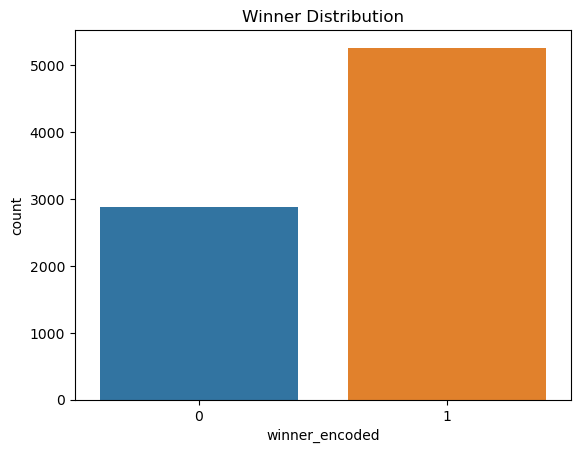

In [98]:
#Visualize dependent variable to assess class distribution
sns.countplot(x='winner_encoded', data=df)

#Add a title and display the plot
plt.title('Winner Distribution')
plt.show()

Will need to undersample as the classes seem somewhat imbalanced.

In [102]:
#Drop columns that are names, URLS, or zero-variance variables
df_new = df.drop(['event_name', 'referee', 'winner', 'fight_url', 'event_date', 'event_state', 
                  'event_country', 'event_url', 'f_1_name', 'f_2_name', 'f_1_url', 'f_2_url', 
                  'f_1_fighter_f_name', 'f_1_fighter_l_name', 'f_1_fighter_nickname', 
                  'f_1_fighter_dob','f_1_fighter_url', 'f_2_fighter_f_name', 
                  'f_2_fighter_l_name', 'f_2_fighter_nickname', 'f_2_fighter_dob', 
                  'f_2_fighter_url'], axis=1)


#Find near zero variance columns - empty df so none exist
nums = df_new.select_dtypes(include=np.number)
zero_variance_columns = nums.columns[nums.var() < 0.01].tolist()
print(zero_variance_columns)

['f_1_fighter_Str_Acc', 'f_1_fighter_Str_Def', 'f_1_sub_wins_3', 'f_2_sub_wins_3', 'f_1_sub_losses_3', 'f_2_sub_losses_3', 'f_2_sub_wins_4', 'f_1_sub_losses_4', 'f_2_sub_losses_4', 'f_2_sub_wins_5', 'f_1_sub_losses_5', 'f_2_sub_losses_5', 'f_2_sub_wins_6', 'f_1_sub_losses_6', 'f_2_sub_losses_6', 'f_2_sub_wins_7', 'f_1_sub_losses_7', 'f_2_sub_losses_7', 'f_2_sub_wins_8', 'f_1_sub_losses_8', 'f_2_sub_losses_8', 'f_2_sub_wins_9', 'f_1_sub_losses_9', 'f_2_sub_losses_9', 'f_1_sub_losses_10', 'f_2_sub_losses_10', 'f_1_sub_losses_11', 'f_2_sub_losses_11', 'f_1_sub_losses_12', 'f_2_sub_losses_12', 'f_1_sub_losses_13', 'f_2_sub_losses_13', 'f_1_sub_losses_14', 'f_2_sub_losses_14', 'f_1_sub_losses_15', 'f_2_sub_losses_15']


In [100]:
#Convert finish_time into decimal
df_new.finish_time.dtype

#Pull out minutes
df_new['finish_time_mins'] = df_new['finish_time'].str.extract(r'(.*):', expand=False)
df_new['finish_time_mins'] = df_new['finish_time_mins'].apply(int)
print(df_new['finish_time_mins'].head())

#Pull out seconds - divide by 60 to get decimal
df_new['finish_time_secs'] = df_new['finish_time'].str.extract(r':\s*(.*)')
df_new['finish_time_secs'] = df_new['finish_time_secs'].apply(int)
df_new['finish_time_secs'] = df_new['finish_time_secs'] / 60
print(df_new['finish_time_secs'].head())

#Add these two columns to get finish time and drop them from new df
df_new['finish_time_v2'] = df_new['finish_time_secs'] + df_new['finish_time_mins']
print(df_new['finish_time_v2'].head())
df1 = df_new.drop(['finish_time_secs', 'finish_time_mins', 'finish_time'], axis=1)

0    3
1    1
2    1
3    5
4    5
Name: finish_time_mins, dtype: int64
0    0.650000
1    0.516667
2    0.033333
3    0.000000
4    0.000000
Name: finish_time_secs, dtype: float64
0    3.650000
1    1.516667
2    1.033333
3    5.000000
4    5.000000
Name: finish_time_v2, dtype: float64


In [103]:
#Correlation matrix - check for multicollinearity with y-variable
corr_matrix = nums.corr(method='pearson')
corr_matrix['winner_encoded']

num_rounds               -0.053112
finish_round             -0.034917
f_1_fighter_height_cm     0.071114
f_1_fighter_weight_lbs    0.091438
f_1_fighter_reach_cm      0.062484
f_1_fighter_w             0.118717
f_1_fighter_l             0.000814
f_1_fighter_d             0.040701
f_1_fighter_nc_dq         0.003618
f_1_fighter_SlpM         -0.016371
f_1_fighter_Str_Acc       0.029841
f_1_fighter_SApM         -0.180900
f_1_fighter_Str_Def       0.012930
f_1_fighter_TD_Avg        0.070153
f_1_fighter_TD_Acc        0.075545
f_1_fighter_TD_Def        0.021608
f_1_fighter_Sub_Avg       0.054730
f_2_fighter_height_cm     0.037388
f_2_fighter_weight_lbs    0.079438
f_2_fighter_reach_cm      0.014203
f_2_fighter_w            -0.060552
f_2_fighter_l             0.123484
f_2_fighter_d             0.049882
f_2_fighter_nc_dq         0.049687
f_2_fighter_SlpM         -0.252056
f_2_fighter_Str_Acc      -0.187508
f_2_fighter_SApM         -0.002121
f_2_fighter_Str_Def      -0.159170
f_2_fighter_TD_Avg  

## EDA

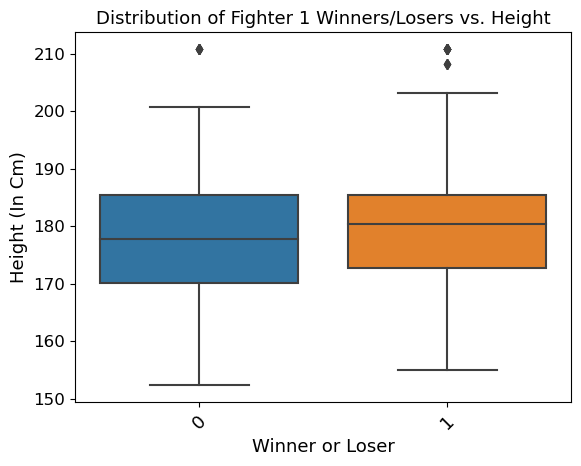

In [104]:
#Fighter height by winning stats
sns.boxplot(x = df1["winner_encoded"], y = df1["f_1_fighter_height_cm"], data=pd.melt(df1))
plt.title('Distribution of Fighter 1 Winners/Losers vs. Height', size=13, color='black')
plt.xlabel('Winner or Loser', fontsize=13, color='black')
plt.ylabel('Height (In Cm)', fontsize=13, color='black')
plt.xticks(fontsize=13, rotation=45)
plt.yticks(fontsize=12)
plt.show()

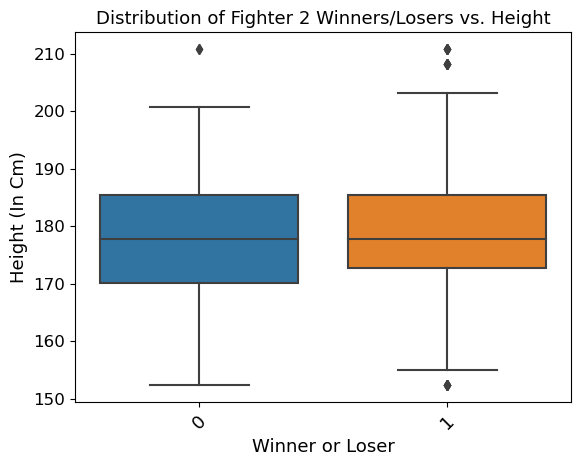

In [298]:
#Fighter height by winning stats
sns.boxplot(x = df1["winner_encoded"], y = df1["f_2_fighter_height_cm"], data=pd.melt(df1))
plt.title('Distribution of Fighter 2 Winners/Losers vs. Height', size=13, color='black')
plt.xlabel('Winner or Loser', fontsize=13, color='black')
plt.ylabel('Height (In Cm)', fontsize=13, color='black')
plt.xticks(fontsize=13, rotation=45)
plt.yticks(fontsize=12)
plt.show()

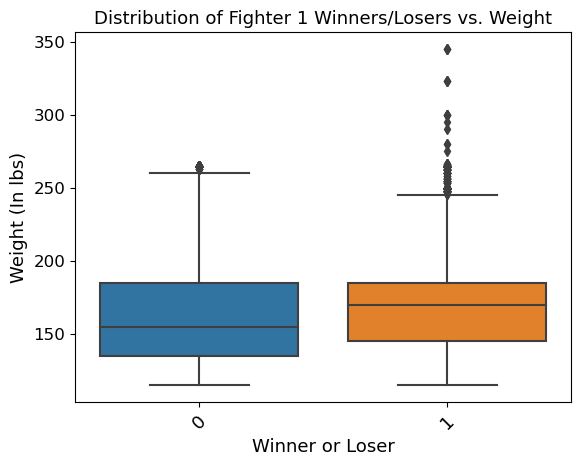

In [105]:
#Fighter weight by winning stats
sns.boxplot(x = df1["winner_encoded"], y = df1["f_1_fighter_weight_lbs"], data=pd.melt(df1))
plt.title('Distribution of Fighter 1 Winners/Losers vs. Weight', size=13, color='black')
plt.xlabel('Winner or Loser', fontsize=13, color='black')
plt.ylabel('Weight (In lbs)', fontsize=13, color='black')
plt.xticks(fontsize=13, rotation=45)
plt.yticks(fontsize=12)
plt.show()

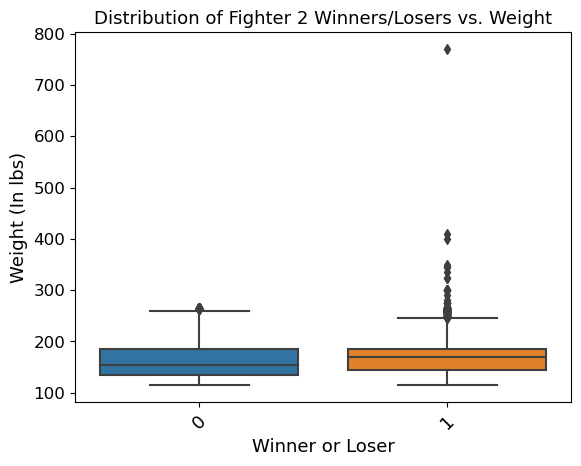

In [299]:
#Fighter weight by winning stats
sns.boxplot(x = df1["winner_encoded"], y = df1["f_2_fighter_weight_lbs"], data=pd.melt(df1))
plt.title('Distribution of Fighter 2 Winners/Losers vs. Weight', size=13, color='black')
plt.xlabel('Winner or Loser', fontsize=13, color='black')
plt.ylabel('Weight (In lbs)', fontsize=13, color='black')
plt.xticks(fontsize=13, rotation=45)
plt.yticks(fontsize=12)
plt.show()

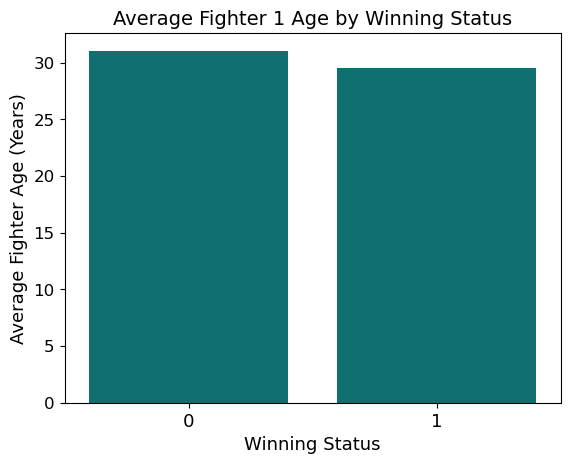

In [107]:
#Age of fighter by winning status
b = df1.groupby("winner_encoded")["f_1_age"].mean().sort_values(ascending=False)[0:5]

b = b.reset_index().rename(columns={"winner_encoded":"Winning Status","f_1_age":"Fighter 1 Age"})

sns.barplot(y = "Fighter 1 Age", x = "Winning Status", data=b, color="teal")

#Making the plot look pretty
plt.title('Average Fighter 1 Age by Winning Status', size=14, color='black')
plt.xticks(fontsize=13)
plt.yticks(fontsize=12)
plt.xlabel('Winning Status', fontsize=13, color='black')
plt.ylabel('Average Fighter Age (Years)', fontsize=13, color='black')
plt.show()

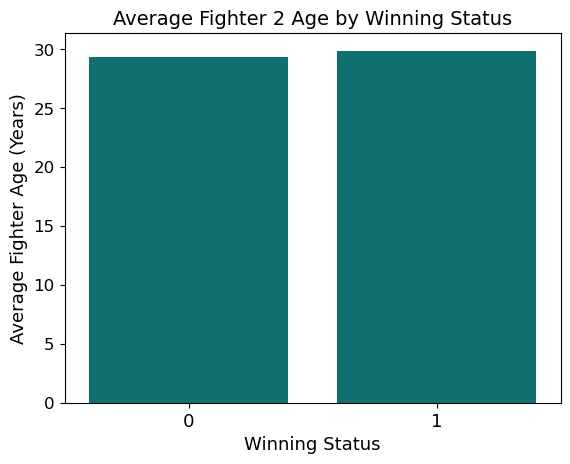

In [108]:
#Age of fighter by winning status
b = df1.groupby("winner_encoded")["f_2_age"].mean().sort_values(ascending=False)[0:5]

b = b.reset_index().rename(columns={"winner_encoded":"Winning Status","f_2_age":"Fighter 2 Age"})

sns.barplot(y = "Fighter 2 Age", x = "Winning Status", data=b, color="teal")

#Making the plot look pretty
plt.title('Average Fighter 2 Age by Winning Status', size=14, color='black')
plt.xticks(fontsize=13)
plt.yticks(fontsize=12)
plt.xlabel('Winning Status', fontsize=13, color='black')
plt.ylabel('Average Fighter Age (Years)', fontsize=13, color='black')
plt.show()

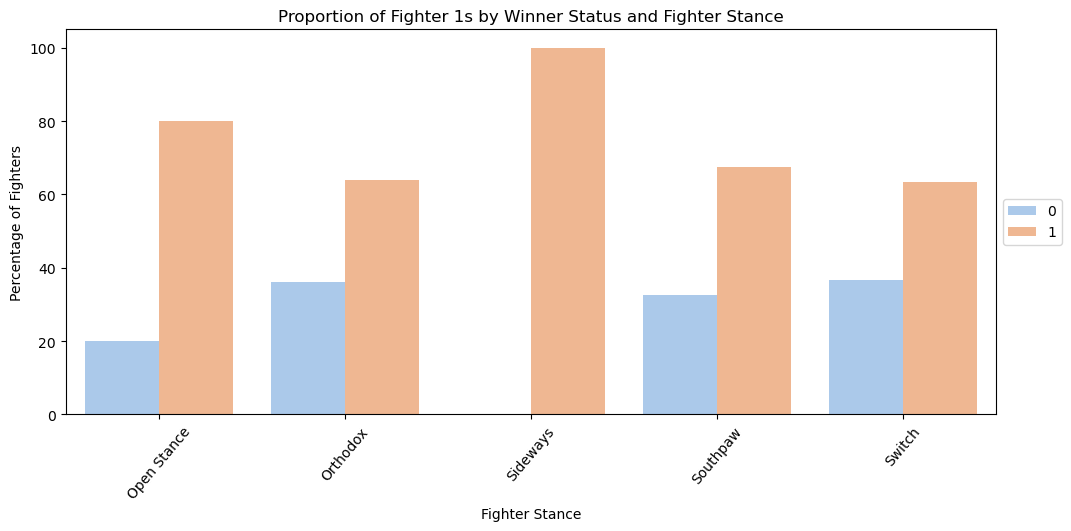

In [109]:
#Find the counts and set index
ndf3 = df1.groupby(['f_1_fighter_stance','winner_encoded']).size().reset_index(name='count')
ndf3 = ndf3.set_index(['f_1_fighter_stance', 'winner_encoded'])

#Calculate grade proportion/percentage
ndf3 = ndf3.groupby(level=0).apply(lambda x: 100 * x / float(x.sum())).reset_index()

#Make the chart look pretty
plt.figure(figsize=(12,5))

ax = sns.barplot(data = ndf3, x = 'f_1_fighter_stance', y = 'count', hue = 'winner_encoded', palette = "pastel")
plt.xticks(rotation = 50)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
plt.title("Proportion of Fighter 1s by Winner Status and Fighter Stance")
plt.xlabel("Fighter Stance")
plt.ylabel("Percentage of Fighters")
plt.show()

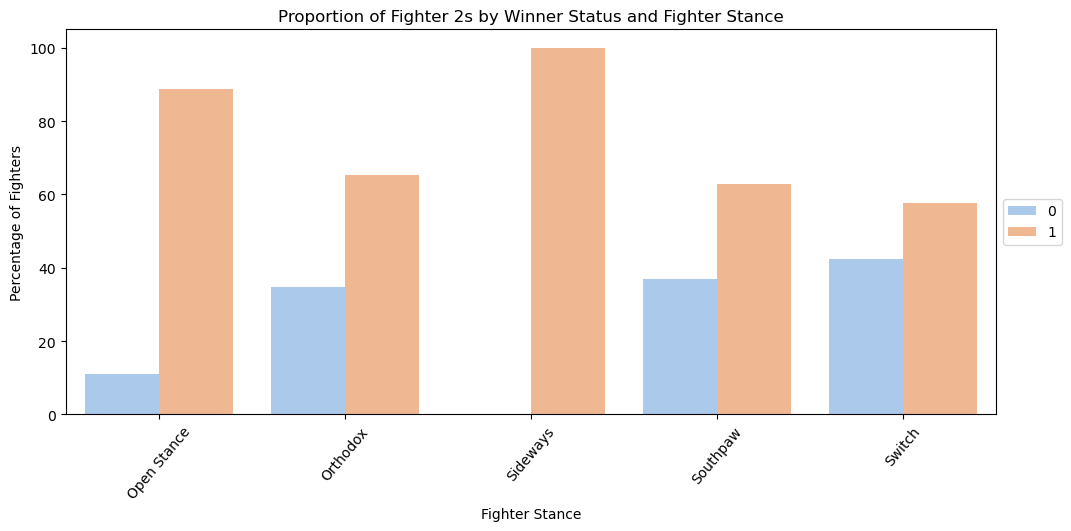

In [110]:
#Find the counts and set index
ndf3 = df1.groupby(['f_2_fighter_stance','winner_encoded']).size().reset_index(name='count')
ndf3 = ndf3.set_index(['f_2_fighter_stance', 'winner_encoded'])

#Calculate grade proportion/percentage
ndf3 = ndf3.groupby(level=0).apply(lambda x: 100 * x / float(x.sum())).reset_index()

#Make the chart look pretty
plt.figure(figsize=(12,5))

ax = sns.barplot(data = ndf3, x = 'f_2_fighter_stance', y = 'count', hue = 'winner_encoded', palette = "pastel")
plt.xticks(rotation = 50)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
plt.title("Proportion of Fighter 2s by Winner Status and Fighter Stance")
plt.xlabel("Fighter Stance")
plt.ylabel("Percentage of Fighters")
plt.show()

## Variable Selection

Going to manually pick my categorical variables to one-hot encode and will have a random forest do variable selection on the numeric variables. 

Technically, gender and weight/weight class being taken into account would mean I'd have to create a separate model for each class. With this dataset that's not possible, so controlling for gender and weight class by not using these variables in the model. 

Categorical variables: title_fight, result, f_1_fighter_stance, f_2_fighter_stance

In [148]:
#Seperate out x and y and drop variables that could be related to winner_encoded
nums = df_new.select_dtypes(include=np.number)
x = nums.drop(['winner_encoded', 'f_2_odds', 'diff_odds', 'f_1_odds', 'f_2_ko_odds',
              'f_1_ko_odds', 'f_1_sub_odds', 'f_2_sub_odds', 'f_1_fighter_weight_lbs',
              'f_2_fighter_weight_lbs', 'f_1_fighter_w', 'f_2_fighter_w', 
               'f_1_fighter_l', 'f_2_fighter_l', 'f_1_total_strikes_succ', 'f_2_sig_strikes_succ',
               'f_1_sig_strikes_succ', 'f_2_total_strikes_succ', 'f_1_ctrl_time_sec',
                'f_2_total_strikes_att', 'f_1_total_strikes_att', 'f_2_sig_strikes_att',
                'f_1_sig_strikes_att', 'f_1_sapm_13', 'f_1_sapm_3', 'f_1_sapm_10', 'f_1_sapm_8',  
                'fight_duration_minutes', 'diff_age', 'f_1_sapm_15',
              'f_1_sapm_6', 'f_2_age', 'f_1_sapm_9', 'f_1_age', 'f_1_sapm_4',
              'f_1_sapm_14', 'f_1_sapm_7', 'f_1_sapm_5', 'f_1_sapm_12', 'f_1_sapm_11', 'f_1_str_def_9',
              'f_1_str_def_12', 'f_1_fighter_height_cm', 'f_1_str_def_7', 'f_1_fighter_reach_cm',
              'f_1_str_def_3', 'f_1_str_def_10', 'f_1_str_def_14', 'f_1_str_def_8',
              'f_1_str_def_15', 'f_1_str_def_4', 'f_2_fighter_height_cm', 'f_1_str_def_13',
              'f_1_str_def_6', 'f_1_str_def_5', 'f_1_str_def_11'], axis=1)
y = nums['winner_encoded']

#Split training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, 
                                                    stratify = y, shuffle=True)
    
model = RandomForestClassifier(n_estimators=20, random_state=42)
model.fit(x_train, y_train)

importances = model.feature_importances_
feature_names = x.columns 
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
    
    
top_n_features = feature_importance_df.head(30)['feature'].tolist()
top_n_features

['f_2_knockdowns',
 'f_2_ctrl_time_sec',
 'f_1_knockdowns',
 'f_2_fighter_SlpM',
 'f_1_takedown_succ',
 'f_2_fighter_reach_cm',
 'f_2_takedown_succ',
 'f_1_submission_att',
 'f_2_fighter_TD_Def',
 'f_2_fighter_Str_Acc',
 'f_1_losses_10',
 'f_2_takedown_att',
 'f_1_fighter_SApM',
 'f_2_submission_att',
 'f_1_fighter_SlpM',
 'f_2_fighter_TD_Avg',
 'f_2_fighter_Str_Def',
 'f_1_fighter_TD_Avg',
 'f_1_fighter_Str_Def',
 'f_1_takedown_att',
 'f_2_fighter_SApM',
 'f_2_fighter_TD_Acc',
 'f_1_fighter_TD_Acc',
 'f_1_fighter_TD_Def',
 'f_1_fighter_Sub_Avg',
 'finish_round',
 'diff_slpm_15',
 'f_1_fighter_Str_Acc',
 'f_2_fighter_Sub_Avg',
 'f_1_str_acc_3']

To be clear, multicollinearity will not affect model performance for classification models. However, it does affect the coefficients/mess with the interpretation of the model. For this reason, I used VIF to iteratively remove any variables with a value higher than 5. The below list is the final result I chose to use as predictors in the model.

In [150]:
#VIF 
#Define the predictor variables
ndf = df1[['f_2_knockdowns','f_2_ctrl_time_sec','f_1_knockdowns','f_2_fighter_SlpM',
           'f_1_takedown_succ','f_2_fighter_reach_cm','f_2_takedown_succ','f_1_submission_att',
           'f_2_fighter_TD_Def','f_2_fighter_Str_Acc','f_1_losses_10','f_2_takedown_att',
           'f_1_fighter_SApM','f_2_submission_att','f_1_fighter_SlpM','f_2_fighter_TD_Avg',
           'f_2_fighter_Str_Def','f_1_fighter_TD_Avg','f_1_fighter_Str_Def','f_1_takedown_att',
            'f_2_fighter_SApM','f_2_fighter_TD_Acc','f_1_fighter_TD_Acc','f_1_fighter_TD_Def',
           'f_1_fighter_Sub_Avg','finish_round','diff_slpm_15','f_1_fighter_Str_Acc',
             'f_2_fighter_Sub_Avg','f_1_str_acc_3','winner_encoded']]
nums = ndf.select_dtypes(include=np.number)
nonasdf = nums.dropna()
X = nonasdf.drop(columns=['winner_encoded'])

#Add a constant to the model (intercept)
X = add_constant(X)

#Calculate VIF for each feature
vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

                 Feature         VIF
0                  const  896.985628
1         f_2_knockdowns    1.100498
2      f_2_ctrl_time_sec    2.471254
3         f_1_knockdowns    1.129845
4       f_2_fighter_SlpM    2.169600
5      f_1_takedown_succ    2.988267
6   f_2_fighter_reach_cm    1.182595
7      f_2_takedown_succ    3.341812
8     f_1_submission_att    1.263996
9     f_2_fighter_TD_Def    1.325281
10   f_2_fighter_Str_Acc    1.418997
11         f_1_losses_10    1.116613
12      f_2_takedown_att    3.018725
13      f_1_fighter_SApM    2.308862
14    f_2_submission_att    1.235225
15      f_1_fighter_SlpM    2.462218
16    f_2_fighter_TD_Avg    1.858779
17   f_2_fighter_Str_Def    1.590428
18    f_1_fighter_TD_Avg    1.968846
19   f_1_fighter_Str_Def    1.640682
20      f_1_takedown_att    3.119556
21      f_2_fighter_SApM    2.006549
22    f_2_fighter_TD_Acc    1.311312
23    f_1_fighter_TD_Acc    1.298328
24    f_1_fighter_TD_Def    1.376076
25   f_1_fighter_Sub_Avg    1.465308
2

## Pre-Development Data Prep

In [166]:
#Clean 'result' column to consolidate diff values 
print(df1['result'].unique())

val = 0

def consolidate(row):
    if row['result'] == '\n\n        \n Submission \n':
        val = "Submission"
    elif row['result'] == '\n\n        \n KO/TKO \n':
        val = "KO/TKO"
    elif row['result'] == "\n\n        \n TKO - Doctor's Stoppage \n":
        val = "TKO - Doctor's Stoppage"
    elif row['result'] == '\n\n        \n DQ \n':
        val = "DQ" 
    else:
        val = row['result']
    return val

df1['result_new'] = df1.apply(consolidate, axis=1)

['Submission' 'KO/TKO' 'Decision - Split' 'Decision - Unanimous'
 "TKO - Doctor's Stoppage" '\n\n        \n KO/TKO \n'
 '\n\n        \n Submission \n' 'Decision'
 "\n\n        \n TKO - Doctor's Stoppage \n" '\n\n        \n DQ \n']


In [167]:
print(df1['result_new'].unique())

['Submission' 'KO/TKO' 'Decision - Split' 'Decision - Unanimous'
 "TKO - Doctor's Stoppage" 'Decision' 'DQ']


In [196]:
#One-hot encode categorical variables
df2 = df1[['f_2_knockdowns','f_2_ctrl_time_sec','f_1_knockdowns','f_2_fighter_SlpM',
           'f_1_takedown_succ','f_2_fighter_reach_cm','f_2_takedown_succ','f_1_submission_att',
           'f_2_fighter_TD_Def','f_2_fighter_Str_Acc','f_1_losses_10','f_2_takedown_att',
           'f_1_fighter_SApM','f_2_submission_att','f_1_fighter_SlpM','f_2_fighter_TD_Avg',
           'f_2_fighter_Str_Def','f_1_fighter_TD_Avg','f_1_fighter_Str_Def','f_1_takedown_att',
            'f_2_fighter_SApM','f_2_fighter_TD_Acc','f_1_fighter_TD_Acc','f_1_fighter_TD_Def',
           'f_1_fighter_Sub_Avg','finish_round','diff_slpm_15','f_1_fighter_Str_Acc',
             'f_2_fighter_Sub_Avg','f_1_str_acc_3','winner_encoded', 'title_fight', 'result_new', 
            'f_1_fighter_stance', 'f_2_fighter_stance']]

one_hot_encoded_data = pd.get_dummies(df2, columns = ['title_fight', 'result_new', 
                                                         'f_1_fighter_stance', 
                                                         'f_2_fighter_stance'])
one_hot_encoded_data.head()

,f_2_knockdowns,f_2_ctrl_time_sec,f_1_knockdowns,f_2_fighter_SlpM,f_1_takedown_succ,f_2_fighter_reach_cm,f_2_takedown_succ,f_1_submission_att,f_2_fighter_TD_Def,f_2_fighter_Str_Acc,...,f_1_fighter_stance_Open Stance,f_1_fighter_stance_Orthodox,f_1_fighter_stance_Sideways,f_1_fighter_stance_Southpaw,f_1_fighter_stance_Switch,f_2_fighter_stance_Open Stance,f_2_fighter_stance_Orthodox,f_2_fighter_stance_Sideways,f_2_fighter_stance_Southpaw,f_2_fighter_stance_Switch
0,0.0,0,0.0,0.00,1.0,177.80,0.0,1.0,0.00,0.00,...,0,1,0,0,0,0,0,0,1,0
1,1.0,2,0.0,6.53,4.0,198.12,0.0,1.0,0.80,0.68,...,0,1,0,0,0,0,0,0,1,0
2,0.0,0,1.0,2.25,0.0,177.80,0.0,0.0,0.00,0.70,...,0,0,0,1,0,0,1,0,0,0
3,0.0,101,0.0,5.11,7.0,160.02,0.0,0.0,0.62,0.66,...,0,1,0,0,0,0,1,0,0,0
4,0.0,62,0.0,7.53,0.0,175.26,0.0,0.0,0.61,0.48,...,0,1,0,0,0,0,1,0,0,0


In [197]:
#Undersampling
#Random sample of 2877 (size of smallest class) to make sure it runs
classes = [1, 0]

partitions = []
for c in classes:
    partition = one_hot_encoded_data[one_hot_encoded_data['winner_encoded'] == c]
    partitions.append(partition.sample(n = 2877, random_state=42))
    
ndf1 = pd.concat(partitions)

In [198]:
len(ndf1)

5754

In [199]:
column_names = ndf1.columns.tolist()
print(column_names)

['f_2_knockdowns', 'f_2_ctrl_time_sec', 'f_1_knockdowns', 'f_2_fighter_SlpM', 'f_1_takedown_succ', 'f_2_fighter_reach_cm', 'f_2_takedown_succ', 'f_1_submission_att', 'f_2_fighter_TD_Def', 'f_2_fighter_Str_Acc', 'f_1_losses_10', 'f_2_takedown_att', 'f_1_fighter_SApM', 'f_2_submission_att', 'f_1_fighter_SlpM', 'f_2_fighter_TD_Avg', 'f_2_fighter_Str_Def', 'f_1_fighter_TD_Avg', 'f_1_fighter_Str_Def', 'f_1_takedown_att', 'f_2_fighter_SApM', 'f_2_fighter_TD_Acc', 'f_1_fighter_TD_Acc', 'f_1_fighter_TD_Def', 'f_1_fighter_Sub_Avg', 'finish_round', 'diff_slpm_15', 'f_1_fighter_Str_Acc', 'f_2_fighter_Sub_Avg', 'f_1_str_acc_3', 'winner_encoded', 'title_fight_False', 'title_fight_True', 'result_new_DQ', 'result_new_Decision', 'result_new_Decision - Split', 'result_new_Decision - Unanimous', 'result_new_KO/TKO', 'result_new_Submission', "result_new_TKO - Doctor's Stoppage", 'f_1_fighter_stance_Open Stance', 'f_1_fighter_stance_Orthodox', 'f_1_fighter_stance_Sideways', 'f_1_fighter_stance_Southpaw', 

In [212]:
#Multiple imputation for missing values
lr = LinearRegression()
imp = IterativeImputer(estimator=lr, verbose=2, max_iter=5, tol=1e-10, imputation_order='roman', random_state=42)
ImputedData = imp.fit_transform(ndf1)

[IterativeImputer] Completing matrix with shape (5754, 50)
[IterativeImputer] Ending imputation round 1/5, elapsed time 0.45
[IterativeImputer] Change: 32.698881668315494, scaled tolerance: 1.1930000000000002e-07 
[IterativeImputer] Ending imputation round 2/5, elapsed time 0.85
[IterativeImputer] Change: 2.074837153482979, scaled tolerance: 1.1930000000000002e-07 
[IterativeImputer] Ending imputation round 3/5, elapsed time 1.22
[IterativeImputer] Change: 0.5933839833663086, scaled tolerance: 1.1930000000000002e-07 
[IterativeImputer] Ending imputation round 4/5, elapsed time 1.61
[IterativeImputer] Change: 0.16298642202003918, scaled tolerance: 1.1930000000000002e-07 
[IterativeImputer] Ending imputation round 5/5, elapsed time 1.98
[IterativeImputer] Change: 0.06915212395095366, scaled tolerance: 1.1930000000000002e-07 


/Users/allisonking/opt/anaconda3/lib/python3.9/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [213]:
Imputed_data = pd.DataFrame(ImputedData)
Imputed_data.columns = ['f_2_knockdowns', 'f_2_ctrl_time_sec', 'f_1_knockdowns', 
                        'f_2_fighter_SlpM', 'f_1_takedown_succ', 'f_2_fighter_reach_cm', 
                        'f_2_takedown_succ', 'f_1_submission_att', 'f_2_fighter_TD_Def', 
                        'f_2_fighter_Str_Acc', 'f_1_losses_10', 'f_2_takedown_att', 
                        'f_1_fighter_SApM', 'f_2_submission_att', 'f_1_fighter_SlpM', 
                        'f_2_fighter_TD_Avg', 'f_2_fighter_Str_Def', 'f_1_fighter_TD_Avg', 
                        'f_1_fighter_Str_Def', 'f_1_takedown_att', 'f_2_fighter_SApM', 
                        'f_2_fighter_TD_Acc', 'f_1_fighter_TD_Acc', 'f_1_fighter_TD_Def', 
                        'f_1_fighter_Sub_Avg', 'finish_round', 'diff_slpm_15', 
                        'f_1_fighter_Str_Acc', 'f_2_fighter_Sub_Avg', 'f_1_str_acc_3', 
                        'winner_encoded', 'title_fight_False', 'title_fight_True', 
                        'result_new_DQ', 'result_new_Decision', 'result_new_Decision - Split', 
                        'result_new_Decision - Unanimous', 'result_new_KO/TKO', 
                        'result_new_Submission', "result_new_TKO - Doctor's Stoppage", 
                        'f_1_fighter_stance_Open Stance', 'f_1_fighter_stance_Orthodox', 
                        'f_1_fighter_stance_Sideways', 'f_1_fighter_stance_Southpaw', 
                        'f_1_fighter_stance_Switch', 'f_2_fighter_stance_Open Stance', 
                        'f_2_fighter_stance_Orthodox', 'f_2_fighter_stance_Sideways', 
                        'f_2_fighter_stance_Southpaw', 'f_2_fighter_stance_Switch']
Imputed_data.head()

,f_2_knockdowns,f_2_ctrl_time_sec,f_1_knockdowns,f_2_fighter_SlpM,f_1_takedown_succ,f_2_fighter_reach_cm,f_2_takedown_succ,f_1_submission_att,f_2_fighter_TD_Def,f_2_fighter_Str_Acc,...,f_1_fighter_stance_Open Stance,f_1_fighter_stance_Orthodox,f_1_fighter_stance_Sideways,f_1_fighter_stance_Southpaw,f_1_fighter_stance_Switch,f_2_fighter_stance_Open Stance,f_2_fighter_stance_Orthodox,f_2_fighter_stance_Sideways,f_2_fighter_stance_Southpaw,f_2_fighter_stance_Switch
0,1.0,193.0,0.0,2.42,2.0,165.100000,0.0,0.0,0.80,0.34,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.00,6.0,199.547957,0.0,0.0,0.00,0.00,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,309.0,0.0,0.97,0.0,187.960000,1.0,1.0,0.66,0.30,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,71.0,0.0,3.25,6.0,182.880000,1.0,0.0,0.59,0.50,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,58.0,2.0,5.33,0.0,177.800000,1.0,0.0,0.79,0.39,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## Model Build Out

In [214]:
#Split training and testing sets
X = Imputed_data.drop(['winner_encoded'], axis=1)
y = Imputed_data["winner_encoded"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### kNN

Classification is computed from a simple majority vote of the nearest neighbors of each point: a query point is assigned the data class which has the most representatives within the nearest neighbors of the point. KNeighborsClassifier implements learning based on the nearest neighbors of each query point, where is an integer value specified by the user.

In [245]:
#kNN 
#Tuning parameters
param_grid = {
    'leaf_size': np.arange(10, 20, 1),
    'n_neighbors': np.arange(10, 20, 1),
    'p': [1, 2, 3]
}

knn = KNeighborsClassifier()

#10-Fold Repeated CV
cvi = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)

knn_clf = GridSearchCV(knn, param_grid, cv=cvi)
knn_clf.fit(X_train, y_train)

GridSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=10, random_state=1),
             estimator=KNeighborsClassifier(),
             param_grid={'leaf_size': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19]),
                         'n_neighbors': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19]),
                         'p': [1, 2, 3]})

In [246]:
#kNN
print("Best parameters and score:", knn_clf.best_score_)
print(knn_clf.best_params_)

Best parameters and score: 0.7157520914863235
{'leaf_size': 10, 'n_neighbors': 19, 'p': 1}


In [287]:
y_pred_knn = knn_clf.predict(X_test)
print("kNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("kNN Precision:", precision_score(y_test, y_pred_knn, average='weighted'))
print("kNN Recall:", recall_score(y_test, y_pred_knn))

kNN Accuracy: 0.7162709901563404
kNN Precision: 0.7234418254918195
kNN Recall: 0.630184331797235


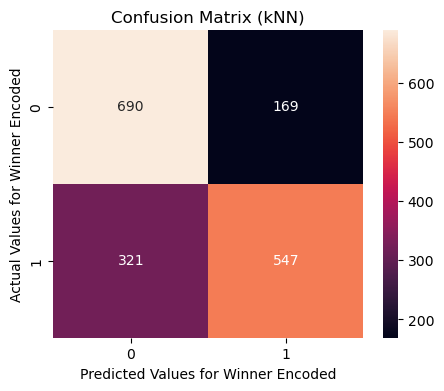

In [248]:
#kNN
cm = confusion_matrix(y_test, y_pred_knn)
cm

#Creating a dataframe for a confusion matrix
cm_df = pd.DataFrame(cm, index = ['0', '1'], columns = ['0', '1'])

#Plotting the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, fmt='g')
plt.title('Confusion Matrix (kNN)')
plt.ylabel('Actual Values for Winner Encoded')
plt.xlabel('Predicted Values for Winner Encoded')
plt.show()

In [221]:
#Trying another hyperparameter tuning method - just looking at # of neighbors
#Found these two blocks of code on a Medium blog post and wanted to experiment 
train_score = {}
test_score = {}
n_neighbors = np.arange(2, 30, 1)
for neighbor in n_neighbors:
    knn = KNeighborsClassifier(n_neighbors=neighbor)
    knn.fit(X_train, y_train)
    train_score[neighbor] = knn.score(X_train, y_train)
    test_score[neighbor] = knn.score(X_test, y_test)

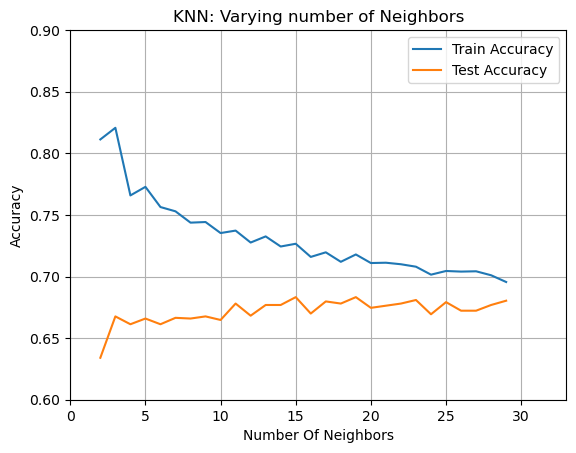

In [222]:
#Plot the above
plt.plot(n_neighbors, train_score.values(), label="Train Accuracy")
plt.plot(n_neighbors, test_score.values(), label="Test Accuracy")
plt.xlabel("Number Of Neighbors")
plt.ylabel("Accuracy")
plt.title("KNN: Varying number of Neighbors")
plt.legend()
plt.xlim(0, 33)
plt.ylim(0.60, 0.90)
plt.grid()
plt.show()

In [223]:
for key, value in test_score.items():
    if value == max(test_score.values()):
        print(key)

15
19


In [296]:
knn = KNeighborsClassifier(n_neighbors=19)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("kNN Accuracy Using 19 Neighbors only:", accuracy_score(y_test, y_pred_knn))

kNN Accuracy Using 19 Neighbors only: 0.6832657788071801


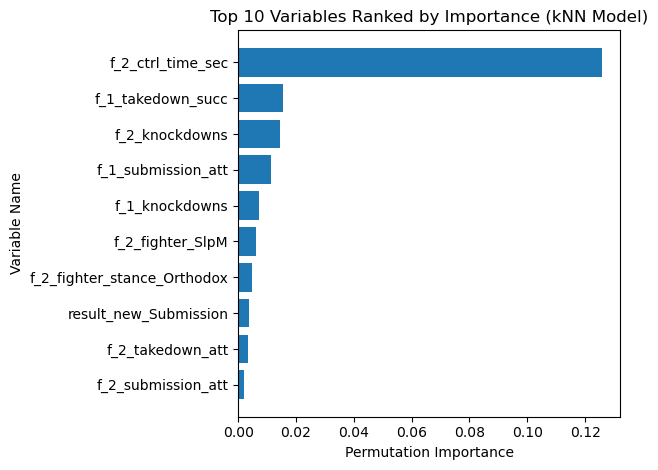

In [303]:
knn1 = KNeighborsClassifier(leaf_size=10, n_neighbors=19, p=1)
knn1.fit(X_train, y_train)

feature_names = ['f_2_knockdowns', 'f_2_ctrl_time_sec', 'f_1_knockdowns', 
                        'f_2_fighter_SlpM', 'f_1_takedown_succ', 'f_2_fighter_reach_cm', 
                        'f_2_takedown_succ', 'f_1_submission_att', 'f_2_fighter_TD_Def', 
                        'f_2_fighter_Str_Acc', 'f_1_losses_10', 'f_2_takedown_att', 
                        'f_1_fighter_SApM', 'f_2_submission_att', 'f_1_fighter_SlpM', 
                        'f_2_fighter_TD_Avg', 'f_2_fighter_Str_Def', 'f_1_fighter_TD_Avg', 
                        'f_1_fighter_Str_Def', 'f_1_takedown_att', 'f_2_fighter_SApM', 
                        'f_2_fighter_TD_Acc', 'f_1_fighter_TD_Acc', 'f_1_fighter_TD_Def', 
                        'f_1_fighter_Sub_Avg', 'finish_round', 'diff_slpm_15', 
                        'f_1_fighter_Str_Acc', 'f_2_fighter_Sub_Avg', 'f_1_str_acc_3', 
                        'title_fight_False', 'title_fight_True', 
                        'result_new_DQ', 'result_new_Decision', 'result_new_Decision - Split', 
                        'result_new_Decision - Unanimous', 'result_new_KO/TKO', 
                        'result_new_Submission', "result_new_TKO - Doctor's Stoppage", 
                        'f_1_fighter_stance_Open Stance', 'f_1_fighter_stance_Orthodox', 
                        'f_1_fighter_stance_Sideways', 'f_1_fighter_stance_Southpaw', 
                        'f_1_fighter_stance_Switch', 'f_2_fighter_stance_Open Stance', 
                        'f_2_fighter_stance_Orthodox', 'f_2_fighter_stance_Sideways', 
                        'f_2_fighter_stance_Southpaw', 'f_2_fighter_stance_Switch']

perm_importance = permutation_importance(knn1, X_test, y_test)

features = np.array(feature_names)

#Plot variable importance for GB - sort indices of feature importances in descending order
sorted_idx = perm_importance.importances_mean.argsort()[::-1]

#Select top 10 indices
top_10_idx = sorted_idx[:10]

#Plot top 10 bars (reverse to show highest at top)
plt.barh(
    [features[i] for i in top_10_idx[::-1]],  # Feature names (reversed)
    perm_importance.importances_mean[top_10_idx[::-1]]  # Importance values (reversed)
)

plt.xlabel("Permutation Importance")
plt.ylabel("Variable Name")
plt.title("Top 10 Variables Ranked by Importance (kNN Model)")
plt.tight_layout()
plt.show()

### Gradient Boosting

Gradient Boosting works by slowly building a strong model, one tree at a time. Each new tree is trained to fix the mistakes made by the model so far. In binary classification, it's simpler because only one tree is added at each step to improve predictions.

In [251]:
#GB
#Tuning parameters
param_grid = {
    'n_estimators': np.arange(10, 100, 5),
    'learning_rate': np.arange(0, 1, 0.1),
    'max_depth': [1, 2, 3]
}

gbc = GradientBoostingClassifier()

#10-Fold Repeated CV
cvi = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)

gb_clf = GridSearchCV(gbc, param_grid, cv=cvi)
gb_clf.fit(X_train, y_train)

GridSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=10, random_state=1),
             estimator=GradientBoostingClassifier(),
             param_grid={'learning_rate': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
                         'max_depth': [1, 2, 3],
                         'n_estimators': array([10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90,
       95])})

In [250]:
#GradientBoosting
gb_classifier = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

gb_classifier.fit(X_train, y_train)

y_pred = gb_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8407643312101911


In [252]:
#GradientBoosting
print("Best parameters and score:", gb_clf.best_score_)
print(gb_clf.best_params_)

Best parameters and score: 0.8409071268965346
{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 95}


In [286]:
y_pred_gb = gb_clf.predict(X_test)
print("GradientBoosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("GradientBoosting Precision:", precision_score(y_test, y_pred_gb, average='weighted'))
print("GradientBoosting Recall:", recall_score(y_test, y_pred_gb))

GradientBoosting Accuracy: 0.8430804863925883
GradientBoosting Precision: 0.8431262806658818
GradientBoosting Recall: 0.8387096774193549


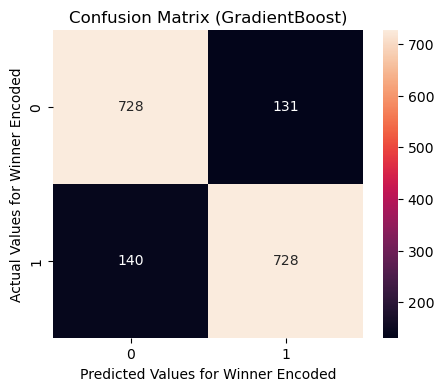

In [254]:
#GradientBoosting
cm = confusion_matrix(y_test, y_pred_gb)
cm

#Creating a dataframe for a confusion matrix
cm_df = pd.DataFrame(cm, index = ['0', '1'], columns = ['0', '1'])

#Plotting the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, fmt='g')
plt.title('Confusion Matrix (GradientBoost)')
plt.ylabel('Actual Values for Winner Encoded')
plt.xlabel('Predicted Values for Winner Encoded')
plt.show()

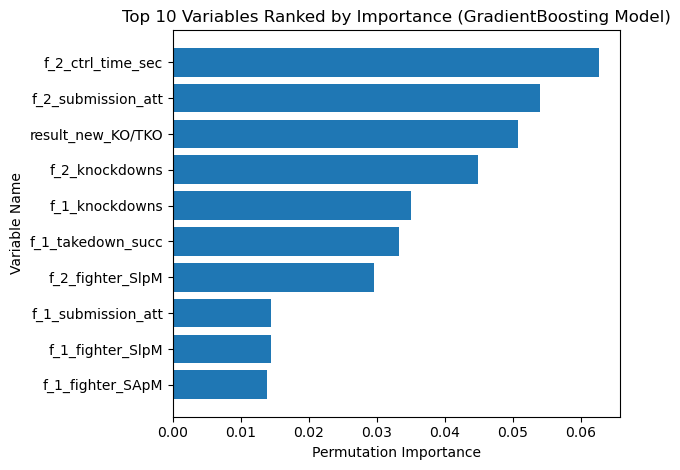

In [277]:
gbc1 = GradientBoostingClassifier(learning_rate=0.2, max_depth=3, n_estimators=95)
gbc1.fit(X_train, y_train)

#feature_names previously defined

perm_importance = permutation_importance(gbc1, X_test, y_test)

features = np.array(feature_names)

#Plot variable importance for GB - sort indices of feature importances in descending order
sorted_idx = perm_importance.importances_mean.argsort()[::-1]

#Select top 10 indices
top_10_idx = sorted_idx[:10]

#Plot top 10 bars (reverse to show highest at top)
plt.barh(
    [features[i] for i in top_10_idx[::-1]],  # Feature names (reversed)
    perm_importance.importances_mean[top_10_idx[::-1]]  # Importance values (reversed)
)

plt.xlabel("Permutation Importance")
plt.ylabel("Variable Name")
plt.title("Top 10 Variables Ranked by Importance (GradientBoosting Model)")
plt.tight_layout()
plt.show()

### Naive Bayes

Naive Bayes methods are a set of supervised learning algorithms based on applying Bayes’ theorem with the “naive” assumption of conditional independence between every pair of features given the value of the class variable. 

In [281]:
#Naive Bayes
#Tuning parameters
param_grid = {
    'var_smoothing': np.logspace(0,-9, num=100)
}

gnb = GaussianNB()

#10-Fold Repeated CV
cvi = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)

gnb_clf = GridSearchCV(gnb, param_grid, cv=cvi)
gnb_clf.fit(X_train, y_train)

GridSearchCV(cv=RepeatedKFold(n_repeats=3, n_splits=10, random_state=1),
             estimator=GaussianNB(),
             param_grid={'var_smoothing': array([1.00000000e+00, 8.11130831e-01, 6.57933225e-01, 5.33669923e-01,
       4.32876128e-01, 3.51119173e-01, 2.84803587e-01, 2.31012970e-01,
       1.87381742e-01, 1.51991108e-01, 1.23284674e-01, 1.00000000e-01,
       8.11130831e-02, 6.57933225e-02, 5.33669923e-...
       1.23284674e-07, 1.00000000e-07, 8.11130831e-08, 6.57933225e-08,
       5.33669923e-08, 4.32876128e-08, 3.51119173e-08, 2.84803587e-08,
       2.31012970e-08, 1.87381742e-08, 1.51991108e-08, 1.23284674e-08,
       1.00000000e-08, 8.11130831e-09, 6.57933225e-09, 5.33669923e-09,
       4.32876128e-09, 3.51119173e-09, 2.84803587e-09, 2.31012970e-09,
       1.87381742e-09, 1.51991108e-09, 1.23284674e-09, 1.00000000e-09])})

In [282]:
#Naive Bayes
print("Best parameters and score:", gnb_clf.best_score_)
print(gnb_clf.best_params_)

Best parameters and score: 0.7748427012991288
{'var_smoothing': 1e-06}


In [285]:
y_pred_gnb = gnb_clf.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_gnb))
print("Naive Bayes Precision:", precision_score(y_test, y_pred_gnb, average='weighted'))
print("Naive Bayes Recall:", recall_score(y_test, y_pred_gnb))

Naive Bayes Accuracy: 0.7544875506658946
Naive Bayes Precision: 0.7691896807273532
Naive Bayes Recall: 0.6405529953917051


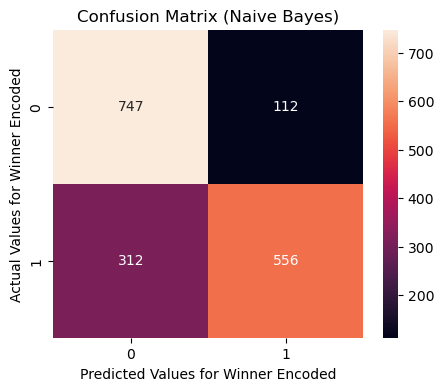

In [284]:
#Naive Bayes
cm = confusion_matrix(y_test, y_pred_gnb)
cm

#Creating a dataframe for a confusion matrix
cm_df = pd.DataFrame(cm, index = ['0', '1'], columns = ['0', '1'])

#Plotting the confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, fmt='g')
plt.title('Confusion Matrix (Naive Bayes)')
plt.ylabel('Actual Values for Winner Encoded')
plt.xlabel('Predicted Values for Winner Encoded')
plt.show()

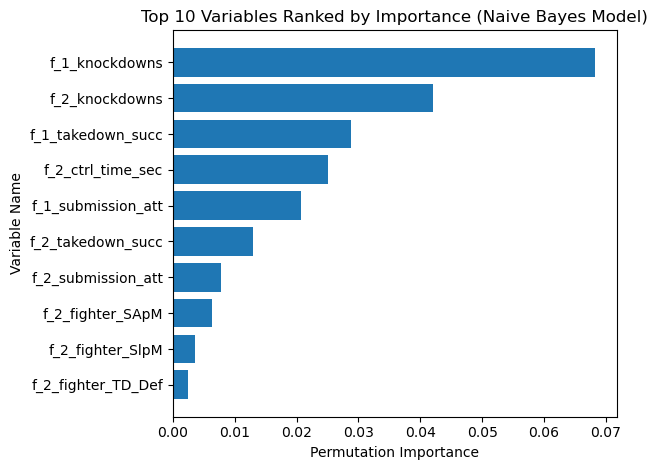

In [290]:
gnb1 = GaussianNB(var_smoothing=1e-06)
gnb1.fit(X_train, y_train)

#feature_names previously defined

perm_importance = permutation_importance(gnb1, X_test, y_test)

features = np.array(feature_names)

#Plot variable importance for GB - sort indices of feature importances in descending order
sorted_idx = perm_importance.importances_mean.argsort()[::-1]

#Select top 10 indices
top_10_idx = sorted_idx[:10]

#Plot top 10 bars (reverse to show highest at top)
plt.barh(
    [features[i] for i in top_10_idx[::-1]],  # Feature names (reversed)
    perm_importance.importances_mean[top_10_idx[::-1]]  # Importance values (reversed)
)

plt.xlabel("Permutation Importance")
plt.ylabel("Variable Name")
plt.title("Top 10 Variables Ranked by Importance (Naive Bayes Model)")
plt.tight_layout()
plt.show()

## Conclusion

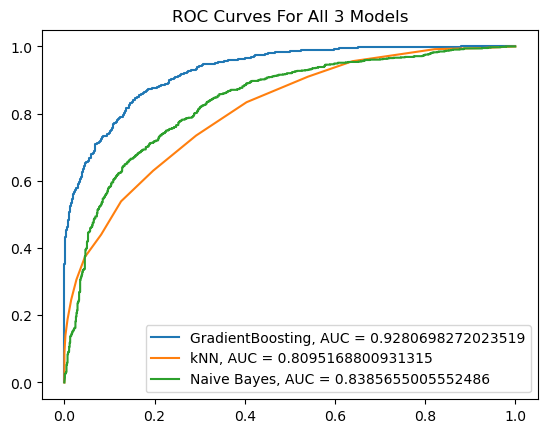

In [300]:
#ROC curve comparing kNN and Gradient Boost
y_pred_proba = gb_clf.predict_proba(X_test)[::,1]
y_pred_proba1 = knn_clf.predict_proba(X_test)[::,1]
y_pred_proba2 = gnb_clf.predict_proba(X_test)[::,1]
fpr1, tpr1, _ = roc_curve(y_test, y_pred_proba)
fpr2, tpr2, _ = roc_curve(y_test, y_pred_proba1)
fpr3, tpr3, _ = roc_curve(y_test, y_pred_proba2)
auc1 = roc_auc_score(y_test, y_pred_proba)
auc2 = roc_auc_score(y_test, y_pred_proba1)
auc3 = roc_auc_score(y_test, y_pred_proba2)
plt.plot(fpr1,tpr1,label="GradientBoosting, AUC = "+str(auc1))
plt.plot(fpr2,tpr2,label="kNN, AUC = "+str(auc2))
plt.plot(fpr3,tpr3,label="Naive Bayes, AUC = "+str(auc3))
plt.legend(loc=4)
plt.title("ROC Curves For All 3 Models")
plt.show()

In [ ]:
#If I wanted to predict the winner of a match (AKA the next titan of the octagon), 
#I would use the below code
gbc1.predict(pd.DataFrame({"f_2_knockdowns":[], "f_2_ctrl_time_sec":[], "f_1_knockdowns":[], 
                        "f_2_fighter_SlpM":[], "f_1_takedown_succ":[], "f_2_fighter_reach_cm":[], 
                        "f_2_takedown_succ":[], "f_1_submission_att":[], "f_2_fighter_TD_Def":[], 
                        "f_2_fighter_Str_Acc":[], "f_1_losses_10":[], "f_2_takedown_att":[], 
                        "f_1_fighter_SApM":[], "f_2_submission_att":[], "f_1_fighter_SlpM":[], 
                        "f_2_fighter_TD_Avg":[], "f_2_fighter_Str_Def":[], "f_1_fighter_TD_Avg":[], 
                        "f_1_fighter_Str_Def":[], "f_1_takedown_att":[], "f_2_fighter_SApM":[], 
                        "f_2_fighter_TD_Acc":[], "f_1_fighter_TD_Acc":[], "f_1_fighter_TD_Def":[], 
                        "f_1_fighter_Sub_Avg":[], "finish_round":[], "diff_slpm_15":[], 
                        "f_1_fighter_Str_Acc":[], "f_2_fighter_Sub_Avg":[], "f_1_str_acc_3":[], 
                        "title_fight_False":[], "title_fight_True":[], "result_new_DQ":[], 
                        "result_new_Decision":[], "result_new_Decision - Split":[], 
                        "result_new_Decision - Unanimous":[], "result_new_KO/TKO":[], 
                        "result_new_Submission":[], "result_new_TKO - Doctor's Stoppage":[], 
                        "f_1_fighter_stance_Open Stance":[], "f_1_fighter_stance_Orthodox":[], 
                        "f_1_fighter_stance_Sideways":[], "f_1_fighter_stance_Southpaw":[], 
                        "f_1_fighter_stance_Switch":[], "f_2_fighter_stance_Open Stance":[], 
                        "f_2_fighter_stance_Orthodox":[], "f_2_fighter_stance_Sideways":[], 
                        "f_2_fighter_stance_Southpaw":[], "f_2_fighter_stance_Switch":[]}))

Gradient Boosting wins! 

Overall, the scores for the various performance metrics were pretty good. I was hoping for at least 70-80% accuracy and precision, and fortunately the results were around that range or better. With that being said, the Gradient Boosting model performed the best in terms of accuracy, precision, recall, and AUC score. Naive Bayes performed the second best and the kNN model performed the worst. 

In terms of practical application, I thought it would be interesting to compare how the Gradient Boosting model ranked the variables in terms of variable importance versus my Naive Bayes model's variable rankings. GB tells us that a fighter's control time in seconds, their attempted number of submissions, if the result is a TKO/KO, and the number of knockdowns are the most important variables (descending) to consider when trying to predict if a fighter will win a match or lose.

The Naive Bayes model provided similar results for variable importance. The top five most important variables in descending order were: the number of knockdowns the fighter got, the number of successful takedowns, the fighter's control time in seconds, the fighter's submission attempts, and and the fighter's strikes absorbed per minute (SApM). Overall, these variables are all things coaches, people placing bets, and fighters themselves should pay attention to when a match is coming up. A fighter may be less vulnerable to losing when their coach or the fighter themselves takes these factors into consideration.

That's all folks!

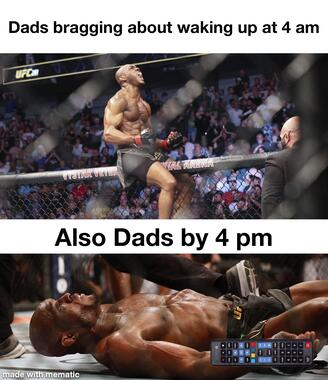